# Is discounting hiding bad products? A second look at the Myntra catalogue (v2)

**Version 1** (February 2026) clustered 117,565 Myntra listings with K-Means on price, discount, rating
and review count (K = 4, elbow method) and found a "Risky" segment: 18,319 products averaging 3.26 stars
despite ~56% discounts, read as "discounting is masking a quality problem; review or delist".

This notebook tests that story in four steps:

1. **Who is in the sample?** v1's cleaning kept only products that were both rated and discounted.
2. **Are there clusters at all**, or did K-Means cut a continuum into four pieces?
3. **How much is a 3.2-star rating worth when it rests on six reviews?** Ratings are shrunk toward the
   catalogue average in proportion to how little evidence they carry (empirical Bayes).
4. **Does deeper discounting go with lower quality**, comparing products of the same brand and category,
   and including the full-price products v1 left out?

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 20261007
R = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")

## 1. The data, and v1 reproduced

A scrape of Myntra product listings (526,564 rows, 13 columns: brand, category, gender, original and
discounted price, average rating and number of reviews) published on Kaggle; `scripts/get_data.py`
fetches a public copy with a pinned checksum. The scrape's date and terms are not documented, so
only aggregates are published here.

In [2]:
raw = pd.read_csv(ROOT / "data" / "myn.csv", low_memory=False)
raw = raw.rename(columns={"DiscountPrice (in Rs)": "DiscountPrice", "OriginalPrice (in Rs)": "OriginalPrice"})
R["rows"], R["unique_products"] = len(raw), int(raw["Product_id"].nunique())
v1 = raw.dropna(subset=["DiscountPrice", "Ratings", "Reviews"]).copy()
v1["DiscountPercent"] = ((v1["OriginalPrice"] - v1["DiscountPrice"]) / v1["OriginalPrice"] * 100).round(2)
FEAT = ["DiscountPrice", "DiscountPercent", "Ratings", "Reviews"]
Xv1 = StandardScaler().fit_transform(v1[FEAT])
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xv1)
v1["cluster"] = km.labels_
prof = v1.groupby("cluster")[FEAT].mean().round(2).assign(products=v1["cluster"].value_counts())
RISKY = int(prof["Ratings"].idxmin())
R["v1_products"] = len(v1)
R["v1_cluster_sizes"] = {int(k): int(v) for k, v in prof["products"].items()}
R["v1_risky"] = {"products": int(prof.loc[RISKY, "products"]), "rating": float(prof.loc[RISKY, "Ratings"]),
                 "discount": float(prof.loc[RISKY, "DiscountPercent"]), "reviews": float(prof.loc[RISKY, "Reviews"])}
print(f"{R['rows']:,} listings, {R['unique_products']:,} unique product ids; v1 kept {len(v1):,}")
print(prof.to_string())

526,564 listings, 526,564 unique product ids; v1 kept 117,565
         DiscountPrice  DiscountPercent  Ratings  Reviews  products
cluster                                                            
0               785.48            59.57     4.21    44.54     60304
1               809.49            54.05     4.10   519.06      5842
2              1506.42            31.56     4.27    33.53     33100
3              1042.92            55.56     3.26    20.40     18319


v1's clusters reproduce exactly (60,304, 5,842, 33,100 and 18,319 products, same means), so this copy of
the data is the one v1 used.

## 2. Who is in the sample?

v1 dropped rows missing a discounted price, a rating or a review count. A missing discounted price
means the product was **not on sale**: it sells at its original price.

In [3]:
rated = raw[raw["Ratings"].notna() & raw["Reviews"].notna()].copy()
rated["on_sale"] = rated["DiscountPrice"].notna()
rated["price"] = rated["DiscountPrice"].fillna(rated["OriginalPrice"])
rated["discount"] = np.where(rated["on_sale"], (rated["OriginalPrice"] - rated["DiscountPrice"]) / rated["OriginalPrice"] * 100, 0.0)
R["rated"], R["rated_share"] = len(rated), float(len(rated) / len(raw))
R["rated_full_price"] = int((~rated["on_sale"]).sum())
comp = rated.groupby("on_sale").agg(products=("Ratings", "size"), mean_rating=("Ratings", "mean"), median_reviews=("Reviews", "median"),
                                    mean_price=("price", "mean"))
print(f"{R['rated']:,} listings are rated ({R['rated_share']:.1%}); {R['rated_full_price']:,} of them are full price and were "
      f"excluded by v1")
print(comp.round(2).to_string())
R["full_price_mean_rating"], R["on_sale_mean_rating"] = float(comp.loc[False, "mean_rating"]), float(comp.loc[True, "mean_rating"])

190,412 listings are rated (36.2%); 72,847 of them are full price and were excluded by v1
         products  mean_rating  median_reviews  mean_price
on_sale                                                   
False       72847         4.13            18.0     1765.41
True       117565         4.08            19.0     1029.77


Only 36.2% of listings carry a rating at all, and v1's cleaning also removed the **72,847 rated products
sold at full price**. A claim that discounting masks poor quality needs exactly the comparison those
products allow, and inside v1's sample it could not be made: every product in it was discounted. Full-
price products rate 4.13 on average against 4.08 for discounted ones.

## 3. Are there clusters at all?

K-Means always returns K groups. Whether they are real is a separate question, answered here two ways
on a 20,000-product sample (silhouette is quadratic in sample size):

- **silhouette**: how much closer each product is to its own cluster than to the next one (0 = no
  structure, 1 = perfectly separated);
- **stability**: re-run K-Means on bootstrap samples and measure agreement with the full-data labels
  (adjusted Rand index; 1 = identical).

   silhouette  bootstrap ARI
2       0.259          0.990
3       0.298          0.796
4       0.285          0.986
5       0.295          0.980
6       0.270          0.826
7       0.229          0.860
8       0.241          0.945


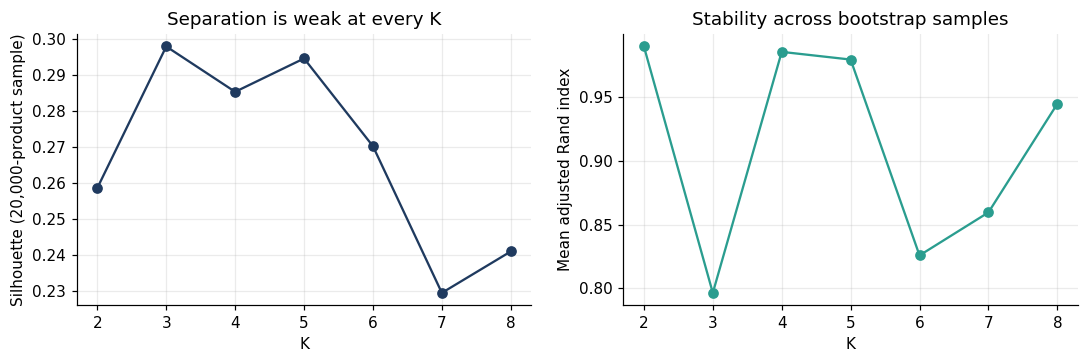

In [4]:
rng = np.random.default_rng(SEED)
sub = rng.choice(len(Xv1), 20000, replace=False)
sil, stab = {}, {}
for k in range(2, 9):
    lab = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(Xv1)
    sil[k] = float(silhouette_score(Xv1[sub], lab[sub], random_state=SEED))
    aris = []
    for b in range(5):
        i = rng.choice(len(Xv1), len(Xv1), replace=True)
        lab_b = KMeans(n_clusters=k, random_state=b, n_init=3).fit(Xv1[i]).predict(Xv1)
        aris.append(adjusted_rand_score(lab, lab_b))
    stab[k] = float(np.mean(aris))
R["silhouette"], R["stability"] = sil, stab
print(pd.DataFrame({"silhouette": sil, "bootstrap ARI": stab}).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(list(sil), list(sil.values()), marker="o", color=INK)
axes[0].set(xlabel="K", ylabel="Silhouette (20,000-product sample)", title="Separation is weak at every K")
axes[1].plot(list(stab), list(stab.values()), marker="o", color=ACCENT)
axes[1].set(xlabel="K", ylabel="Mean adjusted Rand index", title="Stability across bootstrap samples")
save(fig, "cluster_checks.png")

Silhouette never rises above 0.30 for any K (values above about 0.5 indicate well-separated groups),
while the four-cluster solution is very stable across bootstrap samples (adjusted Rand index 0.99).
Together these say K-Means is reliably cutting the same continuum in the same places, not discovering
groups. Segments of a continuum can still be useful labels, but they are not evidence of distinct
kinds of product.

**What defines "Risky"?** A depth-2 decision tree trained to reproduce v1's cluster membership shows
which feature does the work.

In [5]:
tree = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(v1[FEAT], v1["cluster"] == RISKY)
print(export_text(tree, feature_names=FEAT))
R["tree_accuracy_risky"] = float(tree.score(v1[FEAT], v1["cluster"] == RISKY))
thr = float(tree.tree_.threshold[0]) if tree.tree_.feature[0] == FEAT.index("Ratings") else np.nan
R["risky_rating_cut"] = thr
print(f"a depth-2 tree reproduces Risky membership for {R['tree_accuracy_risky']:.1%} of products; first split: Ratings <= {thr:.2f}")

|--- Ratings <= 3.75
|   |--- Ratings <= 3.65
|   |   |--- class: True
|   |--- Ratings >  3.65
|   |   |--- class: False
|--- Ratings >  3.75
|   |--- Ratings <= 3.85
|   |   |--- class: False
|   |--- Ratings >  3.85
|   |   |--- class: False

a depth-2 tree reproduces Risky membership for 96.4% of products; first split: Ratings <= 3.75


A tree that looks only at the rating reproduces "Risky" for 96.4% of products. **The segment is a
ratings cut-off at about 3.7 stars**: price, discount and review count barely enter it. Its high
average discount is simply the catalogue's typical discount.

## 4. How much is a rating worth?

A product's displayed rating is the average of its reviews. With few reviews, that average is mostly
noise. Write the observed average for product *i* with $n_i$ reviews as

$$\bar r_i = \theta_i + \varepsilon_i, \qquad \theta_i \sim N(\mu, \tau^2), \qquad \varepsilon_i \sim N(0, \sigma^2 / n_i),$$

where $\theta_i$ is the product's true quality, $\tau^2$ is how much true quality varies across
products and $\sigma^2$ is how much individual reviews disagree. Then

$$\operatorname{Var}(\bar r_i \mid n_i) = \tau^2 + \sigma^2 / n_i,$$

so plotting the variance of ratings against $1/n$ gives a straight line whose intercept is $\tau^2$
and slope is $\sigma^2$. With both estimated, the best guess of true quality is the **posterior mean**

$$\hat\theta_i = \mu + w_i (\bar r_i - \mu), \qquad w_i = \frac{\tau^2}{\tau^2 + \sigma^2 / n_i},$$

and the chance that a product's true rating is below 3.5 is $\Phi\big((3.5 - \hat\theta_i)/s_i\big)$
with $s_i^2 = \tau^2 \sigma^2 / (n_i \tau^2 + \sigma^2)$.

In [6]:
rated["n"] = rated["Reviews"].clip(lower=1)
bins = pd.qcut(rated["n"], 20, duplicates="drop")
g = rated.groupby(bins, observed=True).agg(var=("Ratings", "var"), inv_n=("n", lambda x: np.mean(1 / x)), k=("Ratings", "size"))
fit = sm.WLS(g["var"], sm.add_constant(g["inv_n"]), weights=g["k"]).fit()
tau2, sigma2 = float(fit.params["const"]), float(fit.params["inv_n"])
mu = float(rated["Ratings"].mean())
R.update({"eb_mu": mu, "eb_tau": float(np.sqrt(tau2)), "eb_sigma": float(np.sqrt(sigma2)), "eb_fit_r2": float(fit.rsquared)})
print(f"mu = {mu:.3f}; true-quality spread tau = {np.sqrt(tau2):.3f} stars; review-to-review spread sigma = {np.sqrt(sigma2):.3f} stars; "
      f"R-squared of the variance line {fit.rsquared:.3f}")
w = tau2 / (tau2 + sigma2 / rated["n"])
rated["theta"] = mu + w * (rated["Ratings"] - mu)
rated["theta_sd"] = np.sqrt(tau2 * sigma2 / (rated["n"] * tau2 + sigma2))
rated["p_below_3_5"] = norm.cdf((3.5 - rated["theta"]) / rated["theta_sd"])
R["reviews_for_half_weight"] = float(sigma2 / tau2)
print(f"a product needs {sigma2 / tau2:.1f} reviews before its own average counts for half of the estimate")

mu = 4.095; true-quality spread tau = 0.336 stars; review-to-review spread sigma = 1.086 stars; R-squared of the variance line 0.891
a product needs 10.5 reviews before its own average counts for half of the estimate


The variance line fits well (R-squared 0.89). Individual reviews disagree by about 1.09 stars, while
products' true quality varies by only 0.34 stars around a mean of 4.09. That ratio is what makes small
samples treacherous: a product needs about 10 reviews before its own average outweighs the catalogue's.

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(g["inv_n"], g["var"], s=g["k"] / 300, color=INK)
xx = np.linspace(0, g["inv_n"].max(), 50)
axes[0].plot(xx, tau2 + sigma2 * xx, color=WARM)
axes[0].set(xlabel="Mean of 1 / reviews (20 bins)", ylabel="Variance of displayed ratings", title="Rating noise falls with evidence")
s = rated.sample(15000, random_state=SEED)
axes[1].scatter(s["n"], s["Ratings"], s=3, alpha=0.25, color=GREY, label="displayed rating")
axes[1].scatter(s["n"], s["theta"], s=3, alpha=0.25, color=INK, label="shrunk estimate")
axes[1].set_xscale("log")
axes[1].set(xlabel="Number of reviews (log scale)", ylabel="Rating", title="Shrinkage pulls thin evidence toward the mean")
axes[1].legend(frameon=False, markerscale=4)
save(fig, "rating_shrinkage.png")

### How many "Risky" products are reliably poor?

In [7]:
v1 = v1.join(rated[["theta", "theta_sd", "p_below_3_5"]])
risky = v1[v1["cluster"] == RISKY]
R["risky_reliably_low"] = int((risky["p_below_3_5"] >= 0.9).sum())
R["risky_reliably_low_share"] = float((risky["p_below_3_5"] >= 0.9).mean())
R["risky_median_reviews"] = float(risky["Reviews"].median())
R["risky_le10_reviews_share"] = float((risky["Reviews"] <= 10).mean())
R["catalogue_reliably_low"] = int((rated["p_below_3_5"] >= 0.9).sum())
R["catalogue_reliably_low_not_risky"] = int(((v1["p_below_3_5"] >= 0.9) & (v1["cluster"] != RISKY)).sum())
R["risky_mean_theta"] = float(risky["theta"].mean())
print(f"Risky segment: {len(risky):,} products, median {R['risky_median_reviews']:.0f} reviews, {R['risky_le10_reviews_share']:.1%} with 10 or fewer")
print(f"mean displayed rating {risky['Ratings'].mean():.2f}, mean shrunk estimate {R['risky_mean_theta']:.2f}")
print(f"reliably below 3.5 stars (probability >= 0.9): {R['risky_reliably_low']:,} ({R['risky_reliably_low_share']:.1%} of the segment)")
print(f"across all {len(rated):,} rated listings: {R['catalogue_reliably_low']:,} reliably below 3.5")

Risky segment: 18,319 products, median 9 reviews, 54.5% with 10 or fewer
mean displayed rating 3.26, mean shrunk estimate 3.72
reliably below 3.5 stars (probability >= 0.9): 531 (2.9% of the segment)
across all 190,412 rated listings: 911 reliably below 3.5


Half of the "Risky" products have 10 reviews or fewer. Once each rating is weighted by its evidence,
the segment's average rises from 3.26 to 3.72 stars, and **only 531 of its 18,319 products (2.9%) are
reliably below 3.5 stars**. Delisting the whole segment, as v1 suggested, would remove thousands of
products whose only problem is a handful of unlucky early reviews. Across the whole rated catalogue,
911 listings (0.5%) are reliably poor: that is the list worth a category manager's time.

## 5. Does deeper discounting go with lower quality?

The question v1's interpretation rests on. Comparing all products mixes brands and categories that
differ in both pricing and quality, so the comparison is made **within brand and category**: each
product's shrunk rating and discount are measured relative to the average of its brand-category group,
and standard errors are clustered by brand. Full-price products (discount 0) are included.

183,476 products in 4,029 brand-category groups of 5 or more
all products compared: -0.011 stars per 10 points of discount (95% CI -0.014 to -0.007)
within brand and category: -0.008 stars per 10 points of discount (95% CI -0.011 to -0.005)
            products  shrunk_rating  reliably_low_share
disc_band                                              
full price     69423          4.135               0.004
1-30%          12045          4.155               0.002
30-50%         29702          4.135               0.002
50-70%         57498          4.082               0.006
over 70%       14808          4.044               0.010


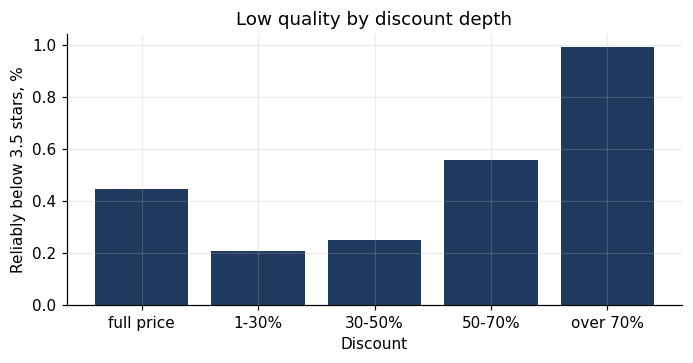

In [8]:
w_ = rated.copy()
w_["grp"] = w_["BrandName"].astype(str) + "|" + w_["Individual_category"].astype(str)
w_ = w_[w_.groupby("grp")["theta"].transform("size") >= 5]
for c in ("theta", "discount"):
    w_[c + "_dm"] = w_[c] - w_.groupby("grp")[c].transform("mean")
ols = sm.OLS(w_["theta_dm"], w_["discount_dm"] / 10).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(w_["BrandName"])[0]})
pooled = sm.OLS(w_["theta"], sm.add_constant(w_["discount"] / 10)).fit(cov_type="cluster", cov_kwds={"groups": pd.factorize(w_["BrandName"])[0]})
R["within_effect_per10"], R["within_ci"] = float(ols.params.iloc[0]), [float(x) for x in ols.conf_int().iloc[0]]
R["pooled_effect_per10"], R["pooled_ci"] = float(pooled.params.iloc[1]), [float(x) for x in pooled.conf_int().iloc[1]]
R["within_products"], R["within_groups"] = len(w_), int(w_["grp"].nunique())
print(f"{len(w_):,} products in {w_['grp'].nunique():,} brand-category groups of 5 or more")
print(f"all products compared: {R['pooled_effect_per10']:+.3f} stars per 10 points of discount "
      f"(95% CI {R['pooled_ci'][0]:+.3f} to {R['pooled_ci'][1]:+.3f})")
print(f"within brand and category: {R['within_effect_per10']:+.3f} stars per 10 points of discount "
      f"(95% CI {R['within_ci'][0]:+.3f} to {R['within_ci'][1]:+.3f})")

w_["disc_band"] = pd.cut(w_["discount"], [-0.1, 0.1, 30, 50, 70, 100], labels=["full price", "1-30%", "30-50%", "50-70%", "over 70%"])
band = w_.groupby("disc_band", observed=True).agg(products=("theta", "size"), shrunk_rating=("theta", "mean"),
                                                 reliably_low_share=("p_below_3_5", lambda p: (p >= 0.9).mean()))
print(band.round(3).to_string())
R["by_discount_band"] = band.round(4).to_dict(orient="index")
fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.bar(band.index.astype(str), band["reliably_low_share"] * 100, color=INK)
ax.set(ylabel="Reliably below 3.5 stars, %", xlabel="Discount", title="Low quality by discount depth")
save(fig, "quality_by_discount.png")

The association exists and is tiny. Within the same brand and category, 10 more points of discount go
with 0.008 fewer stars (95% interval 0.005 to 0.011): a product at 70% off rates about 0.06 stars below
an otherwise similar full-price one. Reliably poor products are slightly more common at discounts
above 70% (1.0%) than at full price (0.4%), but at every discount level they are rare. **The data do
not support "discounting is masking a quality problem"**; at most, the very deepest discounts carry
slightly more duds.

## 6. A watchlist that a category manager could use

Instead of a segment of 18,319 products, a list of brands whose products are *reliably* poor:
at least 20 rated products, ranked by the share whose true rating is below 3.5 with probability 0.9 or
more.

In [9]:
bw = rated.groupby("BrandName").agg(products=("theta", "size"), reliably_low=("p_below_3_5", lambda p: int((p >= 0.9).sum())),
                                    mean_discount=("discount", "mean"), mean_shrunk_rating=("theta", "mean"))
bw = bw[bw["products"] >= 20]
bw["reliably_low_share"] = bw["reliably_low"] / bw["products"]
watch = bw.sort_values(["reliably_low_share", "reliably_low"], ascending=False).head(15)
print(watch.round(3).to_string())
R["brands_with_fifth_or_more_reliably_low"] = int((bw["reliably_low_share"] >= 0.2).sum())
R["brands_20plus"] = len(bw)
R["reliably_low_in_top15_brands_share"] = float(watch["reliably_low"].sum() / max(1, R["catalogue_reliably_low"]))
bw.round(4).to_csv(ROOT / "results" / "brand_quality.csv")
print(f"{R['brands_with_fifth_or_more_reliably_low']} of {R['brands_20plus']} brands with 20+ rated products have a fifth or more reliably poor products; worst share {bw['reliably_low_share'].max():.1%}")

                products  reliably_low  mean_discount  mean_shrunk_rating  reliably_low_share
BrandName                                                                                    
PrettySecrets         26             5          0.000               3.712               0.192
Off Label             65             9          0.000               3.696               0.138
Get Glamr             34             4         40.601               3.948               0.118
Color Cocktail        31             3          0.000               3.880               0.097
Urban Dog            155            14         73.970               3.820               0.090
DODO & MOA           250            22          1.321               3.698               0.088
Silk Bazar            37             3         71.849               3.790               0.081
Myshka               202            15         55.309               3.843               0.074
PAUSE SPORT           96             7         68.960       

No brand with 20 or more rated products has even a fifth of its range reliably below 3.5 stars; the
worst, PrettySecrets, has 5 of 26 (19%). Several brands on the list sell almost entirely at full price
(Off Label, Belle Fille, DODO & MOA), the opposite of the "discounting hides duds" story. Quality
problems here are product-level and rare, not a segment.

## 7. Conclusions and limits

| v1 | v2 |
|---|---|
| 117,565 products analysed | Only rated and discounted products; 72,847 rated full-price products were dropped, removing the comparison the conclusion needed |
| Four segments (K-Means, elbow) | Silhouette 0.30 or less at every K: stable cuts of a continuum, not distinct groups |
| "Risky": 18,319 products, 3.26 stars at ~56% discount | A ratings cut-off (96.4% reproduced by rating alone) resting on thin evidence (median 9 reviews); 531 are reliably below 3.5 stars |
| Discounting masks a quality problem; review or delist | Within brand and category, 10 points of discount = 0.008 fewer stars: negligible. Review the 911 reliably poor listings instead |

**Limits.** A scrape of unknown date and terms; ratings are averages without their distribution, so the
normal model of review noise is an approximation; review counts are capped at 999 (4 products);
reviews are not sales, so nothing here measures revenue.

In [10]:
(ROOT / "results" / "metrics.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, dict)}, indent=1, default=float))

{
 "rows": 526564,
 "unique_products": 526564,
 "v1_products": 117565,
 "rated": 190412,
 "rated_share": 0.3616122636564596,
 "rated_full_price": 72847,
 "full_price_mean_rating": 4.1262742460224855,
 "on_sale_mean_rating": 4.075446774124952,
 "tree_accuracy_risky": 0.9637732318292008,
 "risky_rating_cut": 3.75,
 "eb_mu": 4.094892128647354,
 "eb_tau": 0.3356679764367844,
 "eb_sigma": 1.086232888563331,
 "eb_fit_r2": 0.8907698925183313,
 "reviews_for_half_weight": 10.47191420014484,
 "risky_reliably_low": 531,
 "risky_reliably_low_share": 0.028986298378732463,
 "risky_median_reviews": 9.0,
 "risky_le10_reviews_share": 0.5451170915442982,
 "catalogue_reliably_low": 911,
 "catalogue_reliably_low_not_risky": 50,
 "risky_mean_theta": 3.7177757973633168,
 "within_effect_per10": -0.007837484584170568,
 "within_ci": [
  -0.01069175363131331,
  -0.004983215537027826
 ],
 "pooled_effect_per10": -0.010566633218976867,
 "pooled_ci": [
  -0.014155782448230748,
  -0.0069774839897229855
 ],
 "within_